# 06 — Market Demand and Growth

## How can a product gain prescriptions even while losing market share?

In Notebook 05, we learned that market share determines how the available prescription opportunity is divided among competing products.

But market share tells us only part of the story.

The total size of the market can also change over time.

A therapeutic market may:

- grow as more patients are diagnosed
- contract as treatment patterns change
- experience seasonal variation
- expand even while an individual product loses share

HealthSynth models this overall prescription opportunity as **market demand**.

The relationship is:

```text
Market Demand
        ×
Adjusted Market Share
        =
Product NRx
        ↓
Allocated Across HCPs
```

By the end of this notebook, you will understand:

- what market demand represents
- how growth affects monthly market volume
- how seasonality changes demand
- the difference between market growth and market share
- how a product can lose share but gain prescriptions
- how generated NRx reconciles exactly with upstream demand

## Market Demand Versus Market Share

These terms describe two different commercial questions.

### Market demand

> How large is the total prescribing opportunity?

### Market share

> How is that opportunity divided among products?

For example:

```text
Market demand = 1,000 NRx

Product A share = 50%
Product B share = 30%
Product C share = 20%
```

The implied product opportunities are:

```text
Product A → 500 NRx
Product B → 300 NRx
Product C → 200 NRx
```

If market demand grows, every product has the potential to gain prescriptions—even if the competitive split changes.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from healthsynth.generator import generate

## Generate the Oncology Market

We will use the same oncology training profile as the previous notebook.

This allows us to examine demand, market share, and prescriptions within one consistent commercial world.

In [2]:
datasets = generate(
    config_path="../configs/profiles/oncology_training.yaml",
    output_dir="../output/notebook_06_market_demand",
)

In [3]:
market_demand = datasets["market_demand"].copy()
market_share = datasets["market_share"].copy()
prescriptions = datasets["prescriptions"].copy()
products = datasets["product"].copy()

## Inspect the Market-Demand Dataset

The market-demand table contains one row for each therapeutic area and month.

It records how the total prescribing opportunity is built.

In [4]:
market_demand.head()

,market_id,month,therapeutic_area,base_market_nrx,growth_factor,seasonality_factor,market_nrx
0,MKT_ONC_CA,2023-01-01,Oncology,700.0,1.000000,0.95,663
1,MKT_ONC_CA,2023-02-01,Oncology,700.0,1.010000,0.98,684
2,MKT_ONC_CA,2023-03-01,Oncology,700.0,1.020100,1.00,739
3,MKT_ONC_CA,2023-04-01,Oncology,700.0,1.030301,1.02,741
4,MKT_ONC_CA,2023-05-01,Oncology,700.0,1.040604,1.03,766


The main columns are:

| Column | Meaning |
|---|---|
| `market_id` | Simulated market identifier |
| `month` | Monthly simulation period |
| `therapeutic_area` | Therapeutic market |
| `base_market_nrx` | Starting monthly prescription opportunity |
| `growth_factor` | Cumulative growth applied over time |
| `seasonality_factor` | Monthly seasonal adjustment |
| `market_nrx` | Final simulated market demand |

The final monthly demand is conceptually based on:

```text
Base Market NRx
        ×
Growth Factor
        ×
Seasonality Factor
        =
Monthly Market NRx
```

The final value is expressed as a whole number because prescriptions are counted as integers.

## Prepare the Timeline

In [5]:
market_demand["month"] = pd.to_datetime(
    market_demand["month"]
)

market_share["month"] = pd.to_datetime(
    market_share["month"]
)

prescriptions["rx_date"] = pd.to_datetime(
    prescriptions["rx_date"]
)

market_demand = market_demand.sort_values(
    [
        "therapeutic_area",
        "month",
    ]
).reset_index(drop=True)

## Visualize Monthly Market Demand

The first question is simple:

> How does the overall prescribing opportunity change over time?

In [6]:
monthly_demand = (
    market_demand.groupby("month")["market_nrx"]
    .sum()
    .reset_index()
)

monthly_demand.head()

,month,market_nrx
0,2023-01-01,663
1,2023-02-01,684
2,2023-03-01,739
3,2023-04-01,741
4,2023-05-01,766


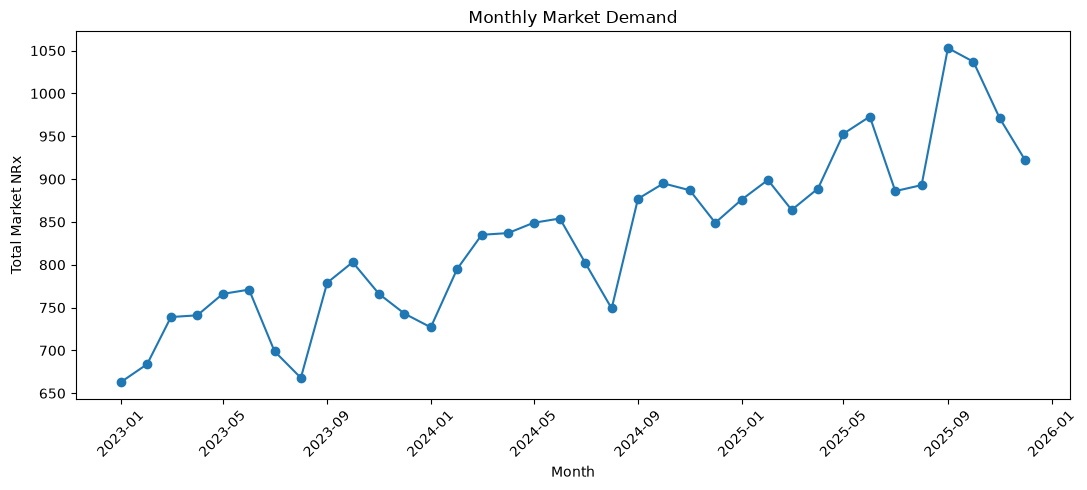

In [7]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_demand["month"],
    monthly_demand["market_nrx"],
    marker="o",
)

plt.title("Monthly Market Demand")
plt.xlabel("Month")
plt.ylabel("Total Market NRx")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

The market does not produce exactly the same number of prescriptions every month.

Demand changes because of two main forces:

- **growth**, which changes the underlying size of the opportunity
- **seasonality**, which creates recurring monthly variation

The observed line therefore reflects both long-term movement and shorter-term fluctuations.

## Understanding the Growth Factor

The growth factor represents cumulative market expansion over time.

A factor of:

- `1.00` means no growth from the starting level
- `1.10` means the market is 10% larger before seasonality
- `1.25` means the market is 25% larger before seasonality

Growth compounds over time rather than being added independently each month.

In [8]:
growth_view = market_demand[
    [
        "month",
        "base_market_nrx",
        "growth_factor",
        "market_nrx",
    ]
].copy()

growth_view.head(12)

,month,base_market_nrx,growth_factor,market_nrx
0,2023-01-01,700.0,1.000000,663
1,2023-02-01,700.0,1.010000,684
2,2023-03-01,700.0,1.020100,739
3,2023-04-01,700.0,1.030301,741
4,2023-05-01,700.0,1.040604,766
5,2023-06-01,700.0,1.051010,771
6,2023-07-01,700.0,1.061520,699
7,2023-08-01,700.0,1.072135,668
8,2023-09-01,700.0,1.082857,779
9,2023-10-01,700.0,1.093685,803


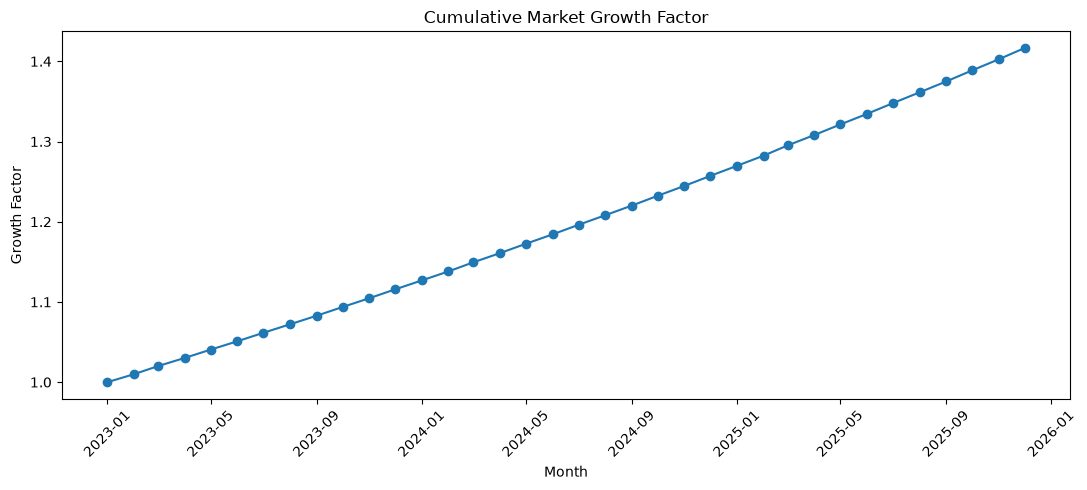

In [9]:
plt.figure(figsize=(11, 5))

plt.plot(
    market_demand["month"],
    market_demand["growth_factor"],
    marker="o",
)

plt.title("Cumulative Market Growth Factor")
plt.xlabel("Month")
plt.ylabel("Growth Factor")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Long-Term Growth

The growth factor should generally rise smoothly when the profile contains a positive monthly growth assumption.

However, final market NRx may not rise smoothly because seasonality is applied after growth.

This distinction is important:

```text
Growth Factor
    = long-term market direction

Market NRx
    = growth adjusted by seasonal conditions
```

## Understanding Seasonality

Some markets experience recurring variation during the year.

Seasonality may reflect:

- treatment cycles
- holidays
- diagnosis patterns
- weather-related disease patterns
- annual prescribing behaviour
- healthcare-system activity

HealthSynth applies a configurable seasonal factor to each month.

A factor:

- above `1.0` increases demand
- below `1.0` reduces demand
- equal to `1.0` leaves demand unchanged

In [10]:
seasonality_view = market_demand[
    [
        "month",
        "seasonality_factor",
        "market_nrx",
    ]
].copy()

seasonality_view["calendar_month"] = (
    seasonality_view["month"].dt.month_name()
)

seasonality_view.head(12)

,month,seasonality_factor,market_nrx,calendar_month
0,2023-01-01,0.95,663,January
1,2023-02-01,0.98,684,February
2,2023-03-01,1.00,739,March
3,2023-04-01,1.02,741,April
4,2023-05-01,1.03,766,May
5,2023-06-01,1.00,771,June
6,2023-07-01,0.92,699,July
7,2023-08-01,0.90,668,August
8,2023-09-01,1.02,779,September
9,2023-10-01,1.05,803,October


In [11]:
seasonality_by_month = (
    seasonality_view.groupby("calendar_month")[
        "seasonality_factor"
    ]
    .mean()
    .reindex(
        [
            "January",
            "February",
            "March",
            "April",
            "May",
            "June",
            "July",
            "August",
            "September",
            "October",
            "November",
            "December",
        ]
    )
    .reset_index()
)

seasonality_by_month

,calendar_month,seasonality_factor
0,January,0.95
1,February,0.98
2,March,1.00
3,April,1.02
4,May,1.03
5,June,1.00
6,July,0.92
7,August,0.90
8,September,1.02
9,October,1.05


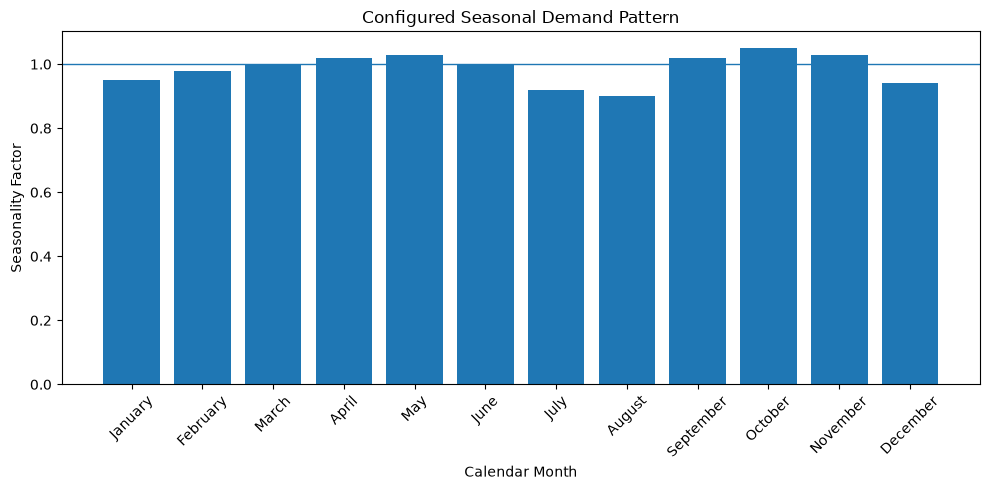

In [12]:
plt.figure(figsize=(10, 5))

plt.bar(
    seasonality_by_month["calendar_month"],
    seasonality_by_month["seasonality_factor"],
)

plt.axhline(
    1.0,
    linewidth=1,
)

plt.title("Configured Seasonal Demand Pattern")
plt.xlabel("Calendar Month")
plt.ylabel("Seasonality Factor")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpreting Seasonality

A month with a factor of `1.06` receives approximately 6% more demand than the growth-adjusted baseline.

A month with a factor of `0.95` receives approximately 5% less.

Seasonality does not change the long-term growth assumption. It temporarily moves monthly demand above or below the underlying trend.

## Reconstruct the Demand Calculation

We can calculate the unrounded monthly demand using:

```text
base_market_nrx
× growth_factor
× seasonality_factor
```

Then compare it with the integer `market_nrx` generated by HealthSynth.

In [13]:
demand_calculation = market_demand[
    [
        "month",
        "base_market_nrx",
        "growth_factor",
        "seasonality_factor",
        "market_nrx",
    ]
].copy()

demand_calculation["unrounded_market_nrx"] = (
    demand_calculation["base_market_nrx"]
    * demand_calculation["growth_factor"]
    * demand_calculation["seasonality_factor"]
)

demand_calculation["rounding_difference"] = (
    demand_calculation["market_nrx"]
    - demand_calculation["unrounded_market_nrx"]
)

demand_calculation.head(12)

,month,base_market_nrx,growth_factor,seasonality_factor,market_nrx,unrounded_market_nrx,rounding_difference
0,2023-01-01,700.0,1.000000,0.95,663,665.000000,-2.000000
1,2023-02-01,700.0,1.010000,0.98,684,692.860000,-8.860000
2,2023-03-01,700.0,1.020100,1.00,739,714.070000,24.930000
3,2023-04-01,700.0,1.030301,1.02,741,735.634914,5.365086
4,2023-05-01,700.0,1.040604,1.03,766,750.275491,15.724509
5,2023-06-01,700.0,1.051010,1.00,771,735.707035,35.292965
6,2023-07-01,700.0,1.061520,0.92,699,683.618977,15.381023
7,2023-08-01,700.0,1.072135,0.90,668,675.445272,-7.445272
8,2023-09-01,700.0,1.082857,1.02,779,773.159688,5.840312
9,2023-10-01,700.0,1.093685,1.05,803,803.858675,-0.858675


The generated market NRx is a whole number, while the calculated value may contain decimals.

Small differences therefore reflect integer rounding rather than unexplained demand.

## Growth and Seasonality Together

To make the distinction clearer, we can compare:

- growth-adjusted demand before seasonality
- final market demand after seasonality

In [14]:
demand_components = market_demand[
    [
        "month",
        "base_market_nrx",
        "growth_factor",
        "seasonality_factor",
        "market_nrx",
    ]
].copy()

demand_components["growth_adjusted_nrx"] = (
    demand_components["base_market_nrx"]
    * demand_components["growth_factor"]
)

demand_components.head()

,month,base_market_nrx,growth_factor,seasonality_factor,market_nrx,growth_adjusted_nrx
0,2023-01-01,700.0,1.000000,0.95,663,700.000000
1,2023-02-01,700.0,1.010000,0.98,684,707.000000
2,2023-03-01,700.0,1.020100,1.00,739,714.070000
3,2023-04-01,700.0,1.030301,1.02,741,721.210700
4,2023-05-01,700.0,1.040604,1.03,766,728.422807


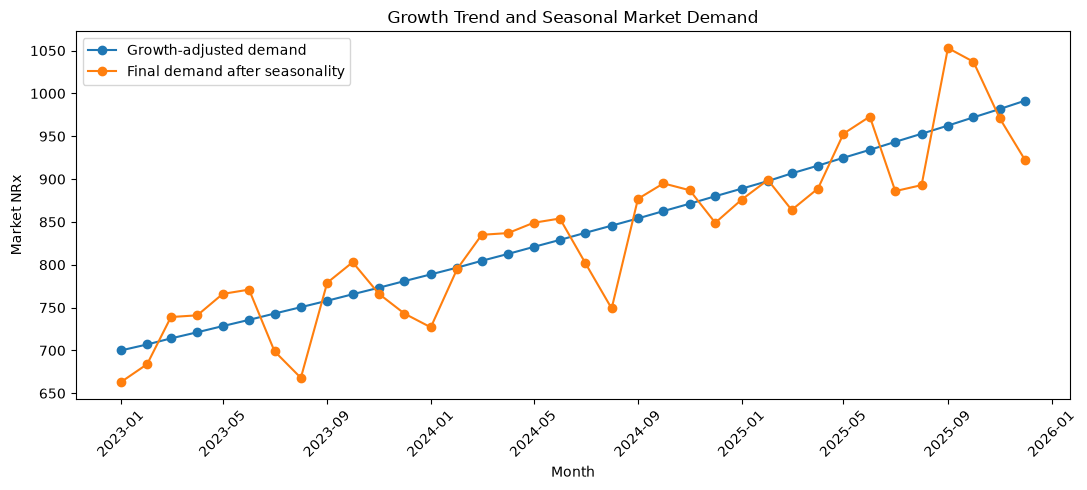

In [15]:
plt.figure(figsize=(11, 5))

plt.plot(
    demand_components["month"],
    demand_components["growth_adjusted_nrx"],
    marker="o",
    label="Growth-adjusted demand",
)

plt.plot(
    demand_components["month"],
    demand_components["market_nrx"],
    marker="o",
    label="Final demand after seasonality",
)

plt.title("Growth Trend and Seasonal Market Demand")
plt.xlabel("Month")
plt.ylabel("Market NRx")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### What the Two Lines Show

The growth-adjusted series reveals the underlying long-term trend.

The final market-demand series moves around that trend because of seasonality.

This is similar to many real-world time series:

```text
Underlying Trend
        +
Recurring Seasonal Pattern
        =
Observed Monthly Volume
```

## From Market Demand to Product Prescriptions

HealthSynth does not assign the full market demand to every product.

It first divides the market using adjusted market share.

```text
Monthly Market NRx
        ×
Product Market Share
        =
Product NRx
```

We will join the demand and share datasets to see this relationship.

In [16]:
product_share = market_share.merge(
    products[
        [
            "product_id",
            "product_name",
        ]
    ],
    on="product_id",
    how="left",
)

product_opportunity = product_share.merge(
    market_demand[
        [
            "market_id",
            "therapeutic_area",
            "month",
            "market_nrx",
        ]
    ],
    on=[
        "market_id",
        "therapeutic_area",
        "month",
    ],
    how="left",
)

product_opportunity["expected_product_nrx"] = (
    product_opportunity["market_nrx"]
    * product_opportunity["adjusted_market_share"]
)

product_opportunity[
    [
        "month",
        "product_name",
        "market_nrx",
        "adjusted_market_share",
        "expected_product_nrx",
    ]
].head(10)

,month,product_name,market_nrx,adjusted_market_share,expected_product_nrx
0,2023-01-01,OncoNova,663,0.419635,278.217932
1,2023-01-01,Tumora,663,0.358438,237.644440
2,2023-01-01,Immunex,663,0.221927,147.137628
3,2023-02-01,OncoNova,684,0.436143,298.321479
4,2023-02-01,Tumora,684,0.338724,231.687409
5,2023-02-01,Immunex,684,0.225133,153.991112
6,2023-03-01,OncoNova,739,0.415505,307.058441
7,2023-03-01,Tumora,739,0.360392,266.329981
8,2023-03-01,Immunex,739,0.224102,165.611578
9,2023-04-01,OncoNova,741,0.426871,316.311286


## Market Growth Can Offset Share Loss

Consider this example:

```text
Period 1
Market demand = 1,000
Product share = 40%
Product NRx = 400

Period 2
Market demand = 1,500
Product share = 35%
Product NRx = 525
```

The product lost five percentage points of market share but gained 125 prescriptions.

This is why commercial analysts examine both:

- relative competitive performance
- absolute prescription volume

## Find This Pattern in the Simulation

We can calculate monthly generated NRx by product and compare it with adjusted share.

In [17]:
generated_product_nrx = (
    prescriptions.groupby(
        [
            "rx_date",
            "product_id",
        ]
    )["nrx"]
    .sum()
    .reset_index(name="generated_nrx")
    .rename(columns={"rx_date": "month"})
)

product_performance = product_share[
    [
        "month",
        "product_id",
        "product_name",
        "adjusted_market_share",
    ]
].merge(
    generated_product_nrx,
    on=[
        "month",
        "product_id",
    ],
    how="left",
)

product_performance.head()

,month,product_id,product_name,adjusted_market_share,generated_nrx
0,2023-01-01,P001,OncoNova,0.419635,282
1,2023-01-01,P002,Tumora,0.358438,231
2,2023-01-01,P003,Immunex,0.221927,150
3,2023-02-01,P001,OncoNova,0.436143,311
4,2023-02-01,P002,Tumora,0.338724,220


In [18]:
product_performance = product_performance.sort_values(
    [
        "product_id",
        "month",
    ]
)

product_performance["share_change"] = (
    product_performance.groupby("product_id")[
        "adjusted_market_share"
    ]
    .diff()
)

product_performance["nrx_change"] = (
    product_performance.groupby("product_id")[
        "generated_nrx"
    ]
    .diff()
)

share_down_nrx_up = product_performance[
    (product_performance["share_change"] < 0)
    & (product_performance["nrx_change"] > 0)
]

share_down_nrx_up[
    [
        "month",
        "product_name",
        "adjusted_market_share",
        "share_change",
        "generated_nrx",
        "nrx_change",
    ]
].head(10)

,month,product_name,adjusted_market_share,share_change,generated_nrx,nrx_change
12,2023-05-01,OncoNova,0.423808,-0.003063,326,46.0
24,2023-09-01,OncoNova,0.425838,-0.010990,330,72.0
27,2023-10-01,OncoNova,0.416964,-0.008874,347,17.0
72,2025-01-01,OncoNova,0.425033,-0.018118,361,12.0
75,2025-02-01,OncoNova,0.421502,-0.003532,372,11.0
96,2025-09-01,OncoNova,0.417238,-0.020822,442,45.0
10,2023-04-01,Tumora,0.344816,-0.015576,285,28.0
25,2023-09-01,Tumora,0.343310,-0.007477,264,20.0
34,2023-12-01,Tumora,0.345303,-0.005955,251,3.0
37,2024-01-01,Tumora,0.344995,-0.000308,271,20.0


### Interpreting the Result

These rows show months where a product:

- lost market share compared with the previous month
- still generated more NRx

This is possible because market demand changed at the same time.

The example demonstrates why prescription growth alone does not prove that a product improved its competitive position.

## Compare Market Demand and Product NRx Visually

Choose one product and view its market share and prescription volume over time.

In [19]:
selected_product = products.iloc[0]["product_name"]

selected_performance = product_performance[
    product_performance["product_name"]
    == selected_product
].copy()

selected_performance.head()

,month,product_id,product_name,adjusted_market_share,generated_nrx,share_change,nrx_change
0,2023-01-01,P001,OncoNova,0.419635,282,NaN,NaN
3,2023-02-01,P001,OncoNova,0.436143,311,0.016508,29.0
6,2023-03-01,P001,OncoNova,0.415505,310,-0.020637,-1.0
9,2023-04-01,P001,OncoNova,0.426871,280,0.011365,-30.0
12,2023-05-01,P001,OncoNova,0.423808,326,-0.003063,46.0


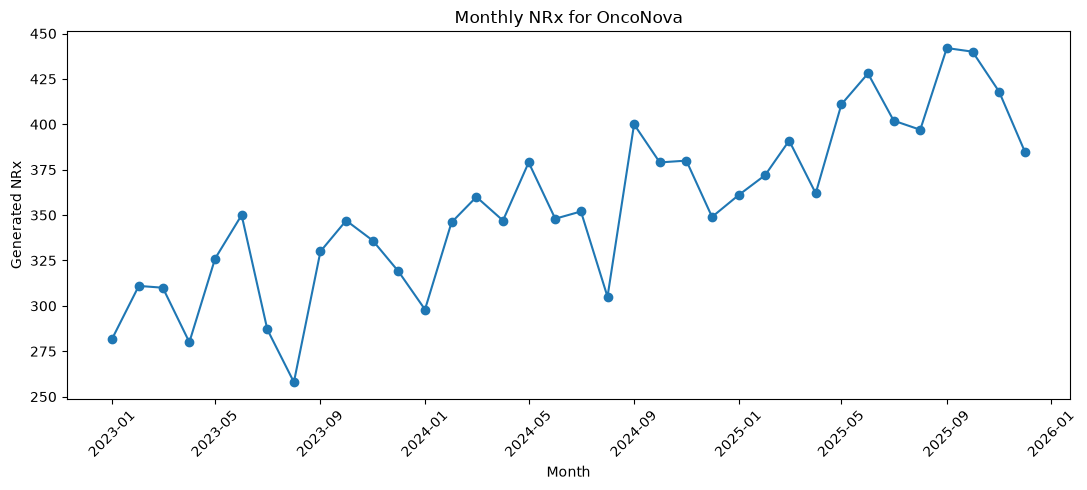

In [20]:
plt.figure(figsize=(11, 5))

plt.plot(
    selected_performance["month"],
    selected_performance["generated_nrx"],
    marker="o",
)

plt.title(f"Monthly NRx for {selected_product}")
plt.xlabel("Month")
plt.ylabel("Generated NRx")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The product-level NRx series reflects two changing inputs:

```text
Total Market Demand
        ×
Product Market Share
```

A change in either factor can affect the final result.

## Reconcile Generated NRx to Market Demand

The final validation rule is:

```text
Total Generated NRx
        =
Total Simulated Market NRx
```

Commercial events may redistribute demand among products, but they should not create or remove prescriptions outside the upstream market model.

In [21]:
monthly_generated_nrx = (
    prescriptions.groupby("rx_date")["nrx"]
    .sum()
    .reset_index(name="generated_nrx")
    .rename(columns={"rx_date": "month"})
)

demand_reconciliation = monthly_demand.merge(
    monthly_generated_nrx,
    on="month",
    how="left",
)

demand_reconciliation["difference"] = (
    demand_reconciliation["generated_nrx"]
    - demand_reconciliation["market_nrx"]
)

demand_reconciliation.head()

,month,market_nrx,generated_nrx,difference
0,2023-01-01,663,663,0
1,2023-02-01,684,684,0
2,2023-03-01,739,739,0
3,2023-04-01,741,741,0
4,2023-05-01,766,766,0


In [22]:
assert (
    demand_reconciliation["difference"] == 0
).all()

print(
    "Monthly generated NRx reconciles exactly "
    "with simulated market demand."
)

Monthly generated NRx reconciles exactly with simulated market demand.


### Why This Reconciliation Matters

Without reconciliation, HealthSynth could produce:

- one market-demand total
- unrelated product prescriptions
- unexplained volume differences

Instead, prescriptions remain grounded in the upstream simulation.

```text
Market Demand
        ↓
Product Allocation
        ↓
HCP Allocation
        ↓
Generated Prescriptions
```

This makes the datasets suitable for learning realistic analytical workflows.

> **Business Insight**
>
> Increasing prescriptions do not always mean improving competitive performance.
>
> A product may gain volume because the entire market is growing, even while losing share to competitors.
>
> Commercial analysts should therefore evaluate:
>
> - market growth
> - market share
> - absolute prescription volume
> - competitor performance
>
> No single measure tells the complete story.

## Key Takeaways

In this notebook, we learned that:

- market demand represents the total prescribing opportunity
- market share determines how that opportunity is divided
- growth changes the underlying size of the market
- seasonality creates recurring monthly variation
- final market NRx combines baseline demand, growth, and seasonality
- a product can lose share while still gaining prescriptions
- absolute volume and relative competitive position must be interpreted together
- generated NRx is allocated from upstream commercial demand
- monthly generated prescriptions reconcile exactly with market NRx

The central relationship is:

```text
Base Demand
        ×
Growth
        ×
Seasonality
        =
Monthly Market Demand
        ×
Adjusted Market Share
        =
Product NRx
```

## Try It Yourself

### Experiment 1 — Increase Market Growth

Create a copy of the oncology profile and increase the monthly growth rate.

Before rerunning, predict:

- How will total market NRx change?
- Will product market shares change?
- Will total product prescriptions increase?

---

### Experiment 2 — Remove Seasonality

Set every monthly seasonality factor to `1.0`.

How does the market-demand chart change?

Does the long-term growth trend become easier to see?

---

### Experiment 3 — Create a Seasonal Peak

Increase the seasonality factor for one month.

Which datasets change?

Does the product portfolio change?

---

### Experiment 4 — Find Share Loss with NRx Growth

Search the simulation for additional months where:

```text
market share decreases
but
generated NRx increases
```

What happened to total market demand in those months?

---

### Experiment 5 — Shrinking Market

Try a negative market-growth rate.

Can a product gain market share while losing prescriptions?

Make a prediction before running the simulation.

## What's Next?

We now understand the foundation of the commercial simulation:

```text
Market Demand
        ×
Market Share
        =
Product Prescriptions
```

The next notebooks introduce commercial events that change this system over time.

In Notebook 07, we will explore a **New Product Launch**.

We will examine:

- product availability
- gradual adoption
- promotional acceleration
- competitive share loss
- prescription impact

Notebook 06 explained how the total opportunity changes.

Notebook 07 introduces a new product competing for that opportunity.